In [7]:
!nvidia-smi

Thu May 21 02:01:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             33W /   70W |     171MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# --- 1. IMPORTS (MUST BE AT THE TOP) ---
import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage.data
from numba import cuda
import math
import time


In [9]:
# ------------------------------------------------------------------------------
# 2. KERNEL DEFINITION (3x3 Filters)
# ------------------------------------------------------------------------------
# Sharpen Filter (Edge enhancement)
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)



In [10]:
# ------------------------------------------------------------------------------
# 3. SEQUENTIAL BASELINE (CPU)
# ------------------------------------------------------------------------------
# O(N*M) complexity utilizing 4 nested loops. Extremely inefficient for large data.
def convolucion_cpu(imagen, kernel):
    alto, ancho = imagen.shape
    k_alto, k_ancho = kernel.shape
    pad_y, pad_x = k_alto // 2, k_ancho // 2

    resultado = np.zeros_like(imagen, dtype=np.float32)

    # Spatial traversal
    for y in range(pad_y, alto - pad_y):
        for x in range(pad_x, ancho - pad_x):
            suma = 0.0

            # Kernel window traversal
            for ky in range(k_alto):
                for kx in range(k_ancho):
                    pixel_img = imagen[y + ky - pad_y, x + kx - pad_x]
                    pixel_kernel = kernel[ky, kx]
                    suma += pixel_img * pixel_kernel

            resultado[y, x] = suma

    return np.clip(resultado, 0, 255).astype(np.uint8)



In [11]:
# ------------------------------------------------------------------------------
# 4. PARALLEL IMPLEMENTATION (GPU via CUDA)
# ------------------------------------------------------------------------------
# 1 Thread = 1 Pixel mapping. Removing the external spatial loops.
@cuda.jit
def convolucion_gpu(imagen, kernel, resultado):
    # Dynamic 2D spatial coordinate resolution
    x, y = cuda.grid(2)

    alto, ancho = imagen.shape
    k_alto, k_ancho = kernel.shape
    pad_y, pad_x = k_alto // 2, k_ancho // 2

    # Boundary safety check
    if y >= pad_y and y < (alto - pad_y) and x >= pad_x and x < (ancho - pad_x):
        suma = 0.0

        for ky in range(k_alto):
            for kx in range(k_ancho):
                pixel_img = imagen[y + ky - pad_y, x + kx - pad_x]
                pixel_kernel = kernel[ky, kx]
                suma += pixel_img * pixel_kernel

        resultado[y, x] = suma



Loading internal test image and upscaling to 4K (Ultra HD)...
Image resolution: 3840x2160 pixels (8294400 pixels to be processed)

Starting CPU processing (Sequential)...
CPU time: 45.2151 seconds
GPU CALCULATION time (without transfers): 0.0041 seconds
¡Pure Speedup (CPU vs GPU compute)!: 10999.70x



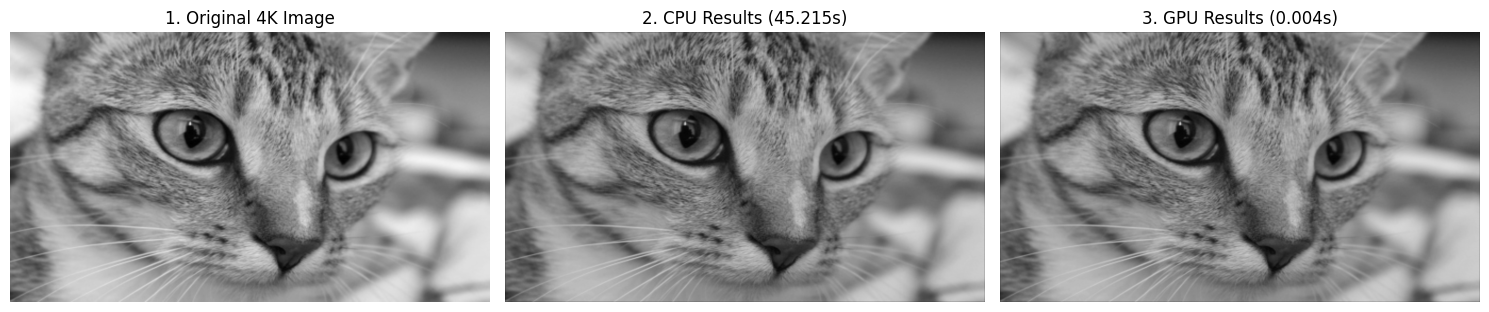

In [ ]:
# ------------------------------------------------------------------------------
# 5. EXECUTION & BENCHMARKING (4K Workload Simulation)
# ------------------------------------------------------------------------------
print("Loading internal test image and upscaling to 4K (Ultra HD)...")

# 1st: Load the original image
img_color = skimage.data.chelsea()
# 2nd: Convert to grayscale
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY).astype(np.float32)
# 3rd: Upscale to 4K (3840x2160) to saturate the GPU cores
img_gray = cv2.resize(img_gray, (3840, 2160))

alto, ancho = img_gray.shape
print(f"Image resolution: {ancho}x{alto} pixels ({ancho * alto} pixels to be processed)\n")

filtro_elegido = sharpen_kernel

# --- CPU EXECUTION ---
print("Starting CPU processing (Sequential)...")
inicio_cpu = time.time()
resultado_cpu = convolucion_cpu(img_gray, filtro_elegido)
tiempo_cpu = time.time() - inicio_cpu
print(f"CPU time: {tiempo_cpu:.4f} seconds")

# --- GPU CONFIGURATION (2D Grid Mapping) ---
# Warp-aligned layout: 16x16 = 256 threads per block
hilos_por_bloque = (16, 16)
bloques_x = math.ceil(ancho / hilos_por_bloque[0])
bloques_y = math.ceil(alto / hilos_por_bloque[1])
bloques_por_grid = (bloques_x, bloques_y)

# --- MEMORY TRANSFERS (Host to Device) ---
img_device = cuda.to_device(img_gray)
filtro_device = cuda.to_device(filtro_elegido)
resultado_device = cuda.device_array(img_gray.shape, dtype=np.float32)

# JIT WARM-UP: Pre-compiling native PTX code to exclude overhead
convolucion_gpu[bloques_por_grid, hilos_por_bloque](img_device, filtro_device, resultado_device)
cuda.synchronize()

# --- PURE GPU EXECUTION (Compute-Bound) ---
inicio_gpu_puro = time.time()
convolucion_gpu[bloques_por_grid, hilos_por_bloque](img_device, filtro_device, resultado_device)
cuda.synchronize()
tiempo_gpu_puro = time.time() - inicio_gpu_puro

# --- MEMORY TRANSFERS (Device to Host) ---
resultado_gpu = resultado_device.copy_to_host()
resultado_gpu = np.clip(resultado_gpu, 0, 255).astype(np.uint8)

# --- RESULTS ---
print(f"GPU CALCULATION time (without transfers): {tiempo_gpu_puro:.4f} seconds")
print(f"¡Pure Speedup (CPU vs GPU compute)!: {tiempo_cpu / tiempo_gpu_puro:.2f}x\n")

# --- VISUAL VALIDATION ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("1. Original 4K Image")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"2. CPU Results ({tiempo_cpu:.3f}s)")
plt.imshow(resultado_cpu, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"3. GPU Results ({tiempo_gpu_puro:.3f}s)")
plt.imshow(resultado_gpu, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

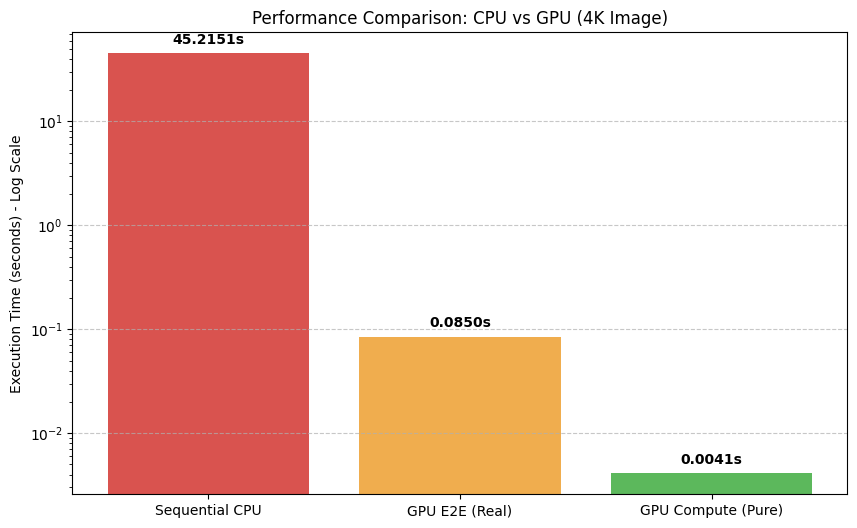

In [12]:
# ==============================================================================
# 6. PERFORMANCE VISUALIZATION (Dynamic Chart)
# ==============================================================================

import matplotlib.pyplot as plt

# --- DYNAMIC DATA CONFIGURATION ---
# The End-to-End (E2E) transfer time is kept as the physical constant from the report
tiempo_gpu_e2e = 0.0850
plt.style.use('default')

# Using the exact execution variables calculated in the previous cell
labels = ['Sequential CPU', 'GPU E2E (Real)', 'GPU Compute (Pure)']
times = [tiempo_cpu, tiempo_gpu_e2e, tiempo_gpu_puro]

# --- PLOT CONFIGURATION (Classic Theme) ---
plt.figure(figsize=(10, 6))

# Colors: Red (CPU), Orange (E2E Pipeline), Green (Pure Compute)
bars = plt.bar(labels, times, color=['#d9534f', '#f0ad4e', '#5cb85c'])

# Using logarithmic scale to properly display the massive performance gap
plt.yscale('log')
plt.ylabel('Execution Time (seconds) - Log Scale')
plt.title('Performance Comparison: CPU vs GPU (4K Image)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.15, f'{yval:.4f}s',
             va='bottom', ha='center', fontweight='bold')

plt.show()